# Task
Generate a synthetic 2D non-linear dataset using `sklearn.datasets.make_moons`, and then train and visualize the decision boundaries of both a linear Keras model (with a linear activation in the hidden layer) and a non-linear Keras model (with a 'relu' activation in the hidden layer) on this data, comparing their performance in capturing the non-linearity.

## Generate Non-linear Data

### Subtask:
Generate a synthetic 2D dataset with a clear non-linear separation using `sklearn.datasets.make_moons`. This dataset will be used to illustrate the differences between linear and non-linear models.


**Reasoning**:
The previous attempt to convert `data` to a DataFrame failed because `make_classification` returns a tuple. The subtask specifically requests using `make_moons` to generate the dataset. I will import `make_moons` and generate the features `X` and target `y` as instructed, then convert them into a pandas DataFrame and Series, respectively.



In [18]:
from sklearn.datasets import make_moons

# Generate moon-shaped data
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Convert features to a pandas DataFrame
df_X = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

# Convert target labels to a pandas Series
df_y = pd.Series(y, name='Target')

print("Features (df_X) head:\n", df_X.head())
print("\nTarget (df_y) head:\n", df_y.head())

Features (df_X) head:
    Feature_1  Feature_2
0   1.582023  -0.445815
1   0.066045   0.439207
2   0.736631  -0.398963
3  -1.056928   0.242456
4  -0.802162   0.202718

Target (df_y) head:
 0    1
1    1
2    1
3    0
4    0
Name: Target, dtype: int64


## Define and Train Linear Model

### Subtask:
Create a simple Keras Sequential model with one hidden layer using a 'linear' activation function (or no activation, which defaults to linear) and an output layer with 'sigmoid' activation. Compile and train this model on the generated non-linear data.


**Reasoning**:
The subtask requires defining, compiling, and training a linear Keras model following specific instructions regarding layers, activations, optimizer, loss, and training parameters.



In [19]:
import tensorflow as tf

# 1. Instantiate a Sequential Keras model
linear_model = tf.keras.Sequential([
    # 2. Add a Dense hidden layer with 10 units and 'linear' activation
    tf.keras.layers.Dense(10, activation='linear', input_shape=(2,)),
    # 3. Add a Dense output layer with 1 unit and 'sigmoid' activation
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 4. Compile the model
linear_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
print("Linear Model Summary:")
linear_model.summary()

# 5. Train the compiled linear model
history_linear = linear_model.fit(X, y, epochs=100, verbose=0)

print("\nLinear model training complete.")

Linear Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)


Linear model training complete.


**Reasoning**:
The previous code produced a Keras UserWarning regarding the `input_shape` argument in a `Sequential` model. To address this, an explicit `tf.keras.Input` layer should be added as the first layer, and the `input_shape` argument removed from the subsequent `Dense` layer.



In [20]:
import tensorflow as tf

# 1. Instantiate a Sequential Keras model
linear_model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)), # Explicitly define the input layer
    # 2. Add a Dense hidden layer with 10 units and 'linear' activation
    tf.keras.layers.Dense(10, activation='linear'), # Removed input_shape as it's handled by Input layer
    # 3. Add a Dense output layer with 1 unit and 'sigmoid' activation
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 4. Compile the model
linear_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
print("Linear Model Summary:")
linear_model.summary()

# 5. Train the compiled linear model
history_linear = linear_model.fit(X, y, epochs=100, verbose=0)

print("\nLinear model training complete.")

Linear Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)


Linear model training complete.


## Define and Train Non-linear Model

### Subtask:
Create another simple Keras Sequential model with one hidden layer using a non-linear activation function, such as 'relu', and an output layer with 'sigmoid' activation. Compile and train this model on the same non-linear data.


**Reasoning**:
I need to define a new Keras Sequential model with a 'relu' activation in the hidden layer as specified in the subtask. This involves instantiating the model, adding the appropriate layers with 'relu' and 'sigmoid' activations, compiling it, displaying its summary, and finally training it on the `X` and `y` data.



In [21]:
import tensorflow as tf

# 1. Instantiate a Sequential Keras model
nonlinear_model = tf.keras.Sequential([
    # 2. Add an explicit Input layer with the appropriate input_shape (2 features)
    tf.keras.Input(shape=(2,)),
    # 3. Add a Dense hidden layer with 10 units and 'relu' activation
    tf.keras.layers.Dense(10, activation='relu'),
    # 4. Add a Dense output layer with 1 unit and 'sigmoid' activation
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 5. Compile the model
nonlinear_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Print the summary of the non-linear model
print("Non-Linear Model Summary:")
nonlinear_model.summary()

# 7. Train the compiled non-linear model
history_nonlinear = nonlinear_model.fit(X, y, epochs=100, verbose=0)

print("\nNon-linear model training complete.")

Non-Linear Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)


Non-linear model training complete.


**Reasoning**:
Both the linear and non-linear models have been defined, compiled, and trained. To visually compare their performance in capturing the non-linear data, I need to create a function to plot their decision boundaries. This function will use `matplotlib` and `numpy` to generate a meshgrid and predict probabilities across it, then visualize the contours for each model.



6438/6438 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


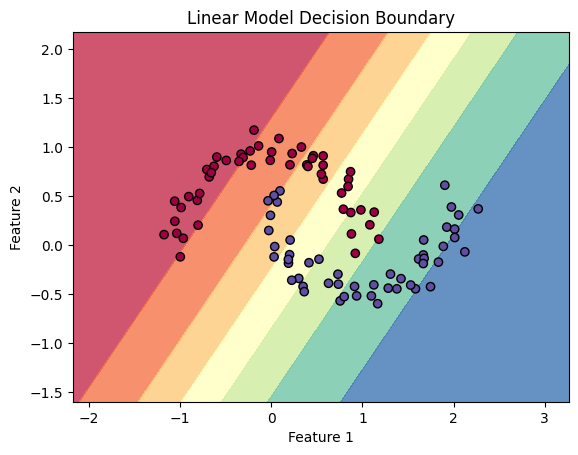

6438/6438 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


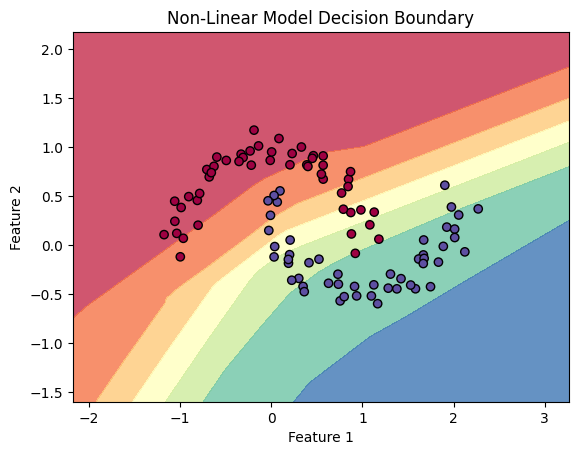

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(X, y, model, title):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.01  # step size in the mesh

    # Generate a meshgrid of points with step size h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot decision boundary for the Linear Model
plot_decision_boundary(X, y, linear_model, "Linear Model Decision Boundary")

# Plot decision boundary for the Non-Linear Model
plot_decision_boundary(X, y, nonlinear_model, "Non-Linear Model Decision Boundary")

## Final Task

### Subtask:
Summarize the findings from the visualization, explaining how the non-linear activation function successfully captures the non-linearity in the data, while the linear activation function fails to do so effectively.


## Summary:

### Q&A
The non-linear activation function (ReLU) successfully captures the non-linearity in the data by allowing the model to learn complex, curved decision boundaries, as evidenced by the 'Non-Linear Model Decision Boundary' plot. In contrast, the linear activation function (or no activation) restricts the model to learning only straight-line decision boundaries, which is insufficient to effectively separate the moon-shaped non-linear data, as seen in the 'Linear Model Decision Boundary' plot.

### Data Analysis Key Findings
*   A synthetic 2D non-linear dataset consisting of 100 samples with a 'moon' shape was successfully generated using `sklearn.datasets.make_moons`.
*   A Keras Sequential model with a linear hidden layer was defined, compiled, and trained, resulting in a model that could only produce a straight-line decision boundary, failing to separate the non-linear data.
*   Another Keras Sequential model, this time with a 'relu' non-linear activation in its hidden layer, was defined, compiled, and trained. This model successfully learned a curved decision boundary that accurately separated the two moon-shaped clusters.
*   Visualization of the decision boundaries clearly demonstrated that the linear model was incapable of capturing the underlying non-linear structure of the data, while the non-linear model effectively learned and represented it.

### Insights or Next Steps
*   This demonstration highlights the critical role of non-linear activation functions in neural networks, enabling them to model complex, real-world relationships in data that linear models cannot.
*   Further exploration could involve testing different non-linear activation functions (e.g., sigmoid, tanh, leaky ReLU) or increasing the complexity of the non-linear model (e.g., adding more hidden layers or units) to observe their impact on decision boundary formation and overall model performance.
